In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# What Is a Neural Mass Model?

A **neural mass model** (NMM) is a low-dimensional dynamical system that describes
the *average* activity of a large population of neurons with a handful of state
variables and ordinary differential equations (ODEs). Instead of tracking the
membrane potential and spikes of every cell, an NMM tracks population-level
quantities — a mean firing rate, an average synaptic current, a mean membrane
potential — and how they evolve in time.

This page explains the core idea, where it sits between single-neuron models and
whole-brain models, and the two flavours of NMM you will meet in ``brainmass``. It
is *understanding-oriented*: light on code, focused on intuition. For hands-on
recipes, see the {doc}`/tutorials/index`; for the package design, see
{doc}`/concepts/architecture_overview`.

## The mean-field idea

A cortical column or brain region contains on the order of $10^5$–$10^6$ neurons.
Simulating each one is expensive and — for many questions about rhythms,
large-scale dynamics, and neuroimaging signals — unnecessary. The **mean-field
approximation** replaces the population by its *statistics*.

The intuition is the law of large numbers. If $N$ neurons each contribute a noisy
spike train, the **population-averaged** firing rate

$$
r(t) \;=\; \frac{1}{N}\sum_{k=1}^{N} \text{(spikes of neuron $k$ near time $t$)}
$$

fluctuates far less than any single neuron and, in the large-$N$ limit, follows a
smooth, *deterministic* equation. A neural mass model is a closed set of ODEs for
such population averages, for example a mean rate $r$ and a mean membrane potential
$v$:

$$
\tau \,\dot r = F(r, v, \text{input}), \qquad
\tau \,\dot v = G(r, v, \text{input}).
$$

The functions $F$ and $G$ encode the population's input–output behaviour (a
sigmoidal *f–I* curve), its synaptic time constants, and its recurrent
connectivity. The price of this compression is that you give up single-spike
information; the reward is that a whole brain region becomes 1–6 numbers you can
simulate, fit, and differentiate cheaply.

## Populations, not single neurons

It helps to place the NMM on a ladder of abstraction:

| Level | State per unit | Typical # of units for a brain | Captures |
|---|---|---|---|
| Single-neuron (Hodgkin–Huxley, LIF) | membrane potential, gating, spikes | $10^9$–$10^{11}$ | individual spikes, biophysics |
| **Neural mass / mean field** | mean rate / potential (1–6 vars) | tens–hundreds (one per region) | population rhythms, regional dynamics |
| Neural field | activity over a continuous sheet | a field $u(x,t)$ | spatial patterns, travelling waves |

The NMM lives at the **population** rung. One "unit" is not a neuron — it is an
entire population (a column, a region, an excitatory or inhibitory pool). This is
exactly the right granularity for whole-brain modelling, where the data
(EEG/MEG/fMRI) are themselves spatially coarse and reflect *aggregate* activity,
not single cells.

A second key move is the **excitatory–inhibitory (E–I) motif**. Many NMMs model a
region as coupled excitatory and inhibitory pools, because the push–pull between
them generates oscillations (alpha, gamma) and stabilises activity. The
Wilson–Cowan and Jansen–Rit models in ``brainmass`` are built from this motif.

## Two flavours: phenomenological vs physiological

NMMs come in two broad styles, and ``brainmass`` ships both.

**Phenomenological** models aim to reproduce the *qualitative dynamics* — limit
cycles, bistability, bifurcations — with the simplest possible equations, often a
normal form. Their parameters are abstract (a bifurcation parameter, an angular
frequency) rather than biophysical. They are ideal for studying *what kind* of
dynamics a region can produce and for fast, well-conditioned fitting.

- *Hopf / Stuart–Landau* — the normal form of an oscillation; a single
  bifurcation parameter switches a region between a quiet fixed point and a
  self-sustained rhythm. The canonical "house" demo model.
- *FitzHugh–Nagumo, Van der Pol* — excitable / relaxation-oscillator dynamics.
- *Kuramoto* — phase-only oscillators for studying synchronisation.

**Physiological** (biophysical) models keep variables and parameters that map onto
measurable biology — synaptic time constants, membrane capacitance, ion-channel
conductances, firing-rate transfer functions — so their outputs can be compared to
recordings in physical units.

- *Jansen–Rit* — three interacting populations producing realistic EEG-like
  waveforms in millivolts.
- *Wilson–Cowan* — coupled E and I firing rates with sigmoidal transfer.
- *Wong–Wang* — synaptic-gating dynamics used for fMRI/BOLD whole-brain models.
- *Montbrió–Pazó–Roxin, Coombes–Byrne* — **next-generation / exact** mean fields
  derived *exactly* from networks of quadratic-integrate-and-fire neurons, so the
  mean rate and potential carry the right biophysical meaning (see
  {doc}`/concepts/why_differentiable` for why the exact derivation matters).

You can browse the full catalogue with ``brainmass.list_models()`` — let's do
that now.

In [2]:
import brainmass

# A curated registry of the models brainmass ships, with their category,
# number of state variables, and a one-line use case.
print(brainmass.list_models.to_table())

name                     category          #states  use_case                                 
-----------------------  ----------------  -------  -----------------------------------------
HopfStep                 phenomenological  2        Oscillation onset, rhythm generation     
VanDerPolStep            phenomenological  2        Nonlinear relaxation oscillations        
StuartLandauStep         phenomenological  2        Amplitude-controlled oscillations        
FitzHughNagumoStep       phenomenological  2        Excitability, spike generation           
ThresholdLinearStep      phenomenological  2        Fast linear E-I responses                
Generic2dOscillatorStep  phenomenological  2        Flexible planar dynamics (TVB)           
LorenzStep               phenomenological  3        Chaos, coupling test fixture             
LinearStep               phenomenological  1        Baseline node, coupling sanity checks    
WilsonCowanStep          physiological     2        E-I popu

The ``category`` column is exactly the phenomenological / physiological /
network split discussed above, and ``n_state_vars`` is how many ODEs each region
costs you — from a single phase variable up to the six-variable Epileptor.

## Where NMMs sit in whole-brain modelling

A neural mass model is one component in a pipeline that turns anatomy into a
predicted neuroimaging signal:

$$
\underbrace{\text{SC}}_{\text{structural connectivity}}
\;\longrightarrow\;
\underbrace{\text{NMM per region}}_{\text{local dynamics}}
\;\longrightarrow\;
\underbrace{\text{forward model}}_{\text{biophysics of measurement}}
\;\longrightarrow\;
\underbrace{\text{signal}}_{\text{BOLD / EEG / MEG}}
$$

1. **Structural connectivity (SC).** A matrix of inter-region connection weights
   (from diffusion MRI tractography), optionally with a distance matrix that sets
   **conduction delays**. This is the wiring diagram.
2. **A neural mass per region.** Each node runs its own NMM. Regions exchange
   activity through the SC, usually as **diffusive** or **additive** coupling, with
   delays from finite axonal conduction speed. The maths and intuition of coupling
   live in {doc}`/concepts/coupling_and_delays`.
3. **A forward model.** Neural activity is not measured directly. A
   hemodynamic model turns it into **BOLD** (fMRI), and lead-field models project
   dipolar source currents to **EEG/MEG** sensors. See
   {doc}`/concepts/from_activity_to_signals`.
4. **The signal.** The output you compare against data — and, in ``brainmass``,
   the output you can *backpropagate through* to fit parameters.

In ``brainmass`` these four stages map onto ``Network`` (SC + coupling + delays),
the model classes (the per-region NMM), the forward/observation models, and the
``Simulator`` / ``Fitter`` orchestration.

## A small illustrative simulation

To make the mean-field idea concrete, here is a single region modelled as a Hopf
oscillator. With its bifurcation parameter $a > 0$ the region sustains a rhythm;
its two state variables $(x, y)$ trace a limit cycle. This is the entire "model"
— two ODEs standing in for a whole population of neurons.

In [3]:
import brainmass
import brainunit as u

# One region as a supercritical Hopf oscillator (a > 0 -> sustained rhythm).
node = brainmass.HopfStep(in_size=1, a=0.25, w=0.3)

res = brainmass.Simulator(node, dt=0.1 * u.ms).run(
    300 * u.ms,
    monitors=['x', 'y'],
    transient=50 * u.ms,
)

# Two population-level state variables, sampled over time.
print('x shape:', res['x'].shape, ' y shape:', res['y'].shape)
print('time runs from', res['ts'][0], 'to', res['ts'][-1])

x shape: (2500, 1)  y shape: (2500, 1)
time runs from 

50.1 ms to 300. ms


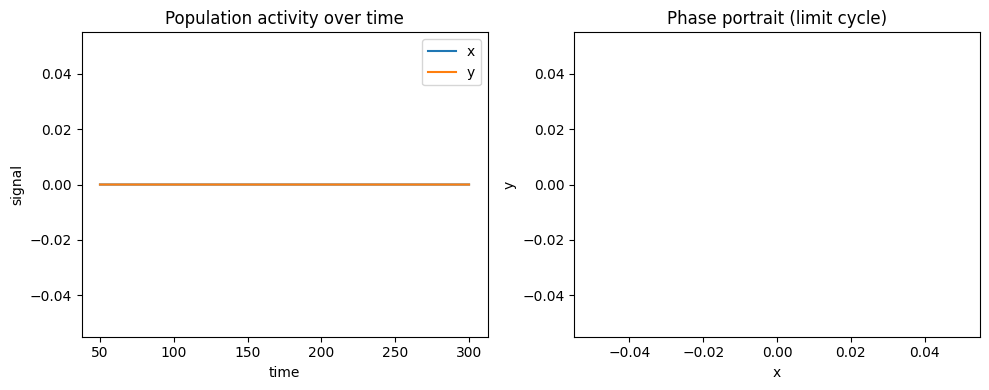

In [4]:
import matplotlib.pyplot as plt
import brainunit as u

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left: the two state variables versus time (the population rhythm).
brainmass.viz.plot_timeseries(res['x'], ts=res['ts'], ax=ax1, labels=['x'])
brainmass.viz.plot_timeseries(res['y'], ts=res['ts'], ax=ax1, labels=['y'])
ax1.set_title('Population activity over time')

# Right: the same trajectory in state space -> a limit cycle.
brainmass.viz.plot_phase_portrait(res['x'][:, 0], res['y'][:, 0], ax=ax2)
ax2.set_title('Phase portrait (limit cycle)')

fig.tight_layout()
plt.show()

The left panel shows the population rhythm; the right shows that the two state
variables settle onto a closed orbit — a **limit cycle**, the signature of a
self-sustained oscillation. A single number, the bifurcation parameter $a$,
controls whether this cycle exists at all. That is the power of the mean-field
abstraction: rich, data-relevant dynamics from a tiny, tractable system.

## Key takeaways

- A neural mass model trades single-neuron detail for a **handful of
  population-averaged ODEs** per region, justified by the mean-field
  approximation.
- A "unit" is a **population/region**, not a neuron — the right granularity for
  whole-brain modelling and coarse neuroimaging data.
- **Phenomenological** models capture qualitative dynamics with abstract
  parameters; **physiological** (incl. next-generation exact) models keep
  biophysical meaning. ``brainmass`` ships both.
- An NMM is one stage of the whole-brain pipeline
  **SC → NMM → forward model → signal**, and in ``brainmass`` the whole pipeline is
  *differentiable*.

## See also

- {doc}`/concepts/why_differentiable` — why a differentiable JAX core changes how
  you fit and train these models.
- {doc}`/concepts/architecture_overview` — how the package realises the pipeline.
- {doc}`/concepts/coupling_and_delays` — wiring regions together.
- {doc}`/concepts/from_activity_to_signals` — turning activity into BOLD / EEG / MEG.
- {doc}`/tutorials/index` — hands-on first simulations.

## References

- Wilson, H. R., & Cowan, J. D. (1972). Excitatory and inhibitory interactions in
  localized populations of model neurons. *Biophysical Journal*, 12(1), 1–24.
- Jansen, B. H., & Rit, V. G. (1995). Electroencephalogram and visual evoked
  potential generation in a mathematical model of coupled cortical columns.
  *Biological Cybernetics*, 73(4), 357–366.
- Deco, G., Jirsa, V. K., Robinson, P. A., Breakspear, M., & Friston, K. (2008).
  The dynamic brain: from spiking neurons to neural masses and cortical fields.
  *PLoS Computational Biology*, 4(8), e1000092.
- Montbrió, E., Pazó, D., & Roxin, A. (2015). Macroscopic description for networks
  of spiking neurons. *Physical Review X*, 5(2), 021028.